In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Fish.csv")
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [3]:
print(df.shape)
df.info()

(159, 7)
<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 8.8 KB


In [4]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [5]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


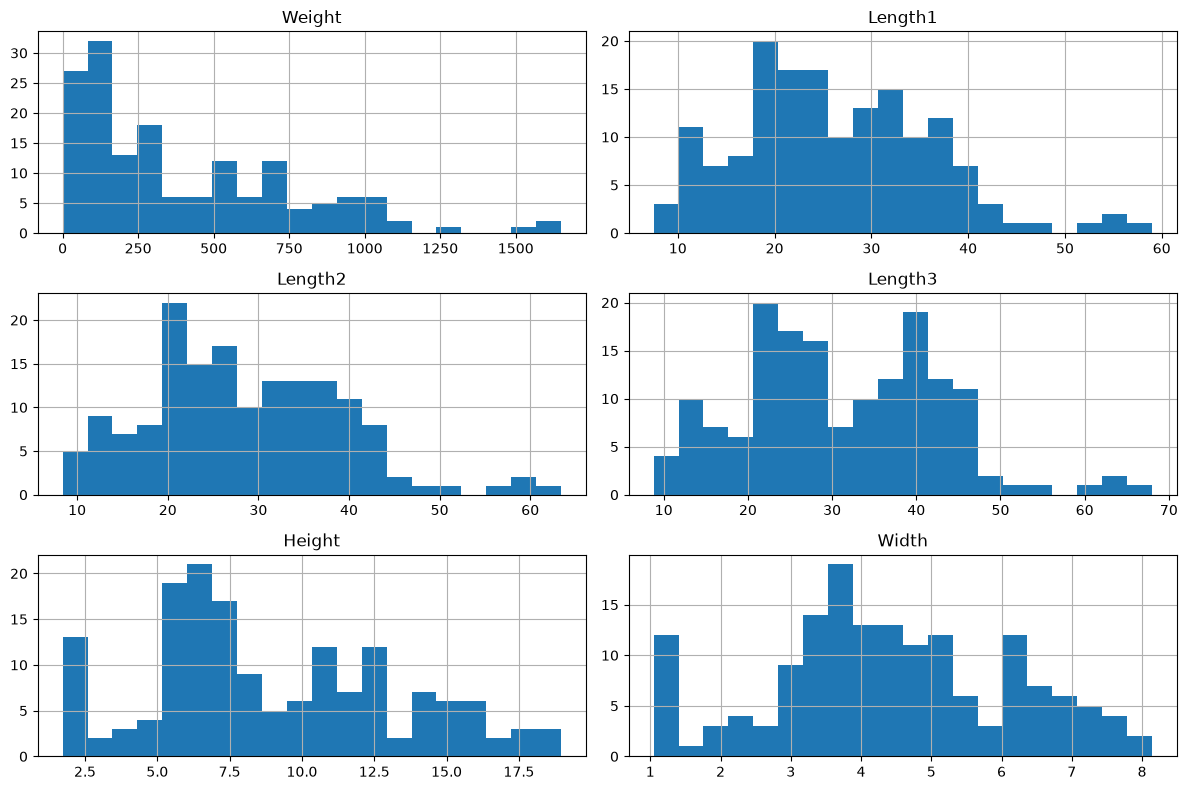

In [6]:
df.hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [7]:
df[df["Weight"] == 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


In [8]:
features = ["Length1", "Length2", "Length3", "Height", "Width"]
target = "Weight"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

In [9]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline R2  :", baseline_r2)

Baseline RMSE: 127.56630833774402
Baseline R2  : 0.87084088241008


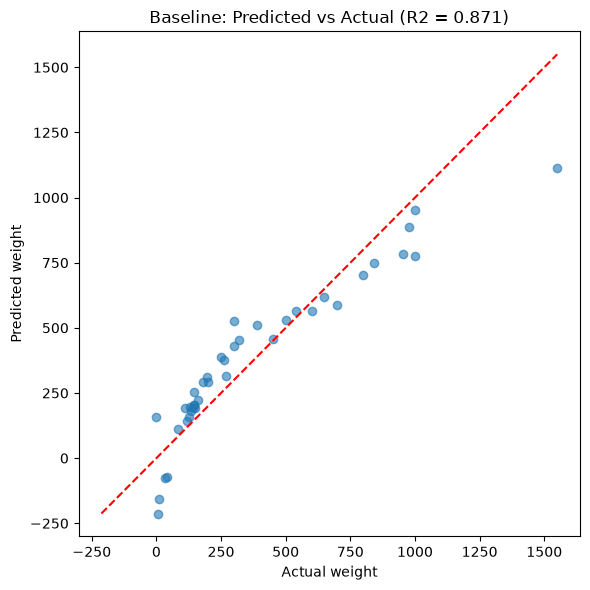

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, baseline_pred, alpha=0.6)
lims = [min(y_test.min(), baseline_pred.min()), max(y_test.max(), baseline_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual weight")
plt.ylabel("Predicted weight")
plt.title(f"Baseline: Predicted vs Actual (R2 = {baseline_r2:.3f})")
plt.tight_layout()
plt.show()

In [11]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
poly_r2 = r2_score(y_test, poly_pred)

print("Polynomial RMSE:", poly_rmse)
print("Polynomial R2  :", poly_r2)

Polynomial RMSE: 55.50849755693335
Polynomial R2  : 0.9755447538180355


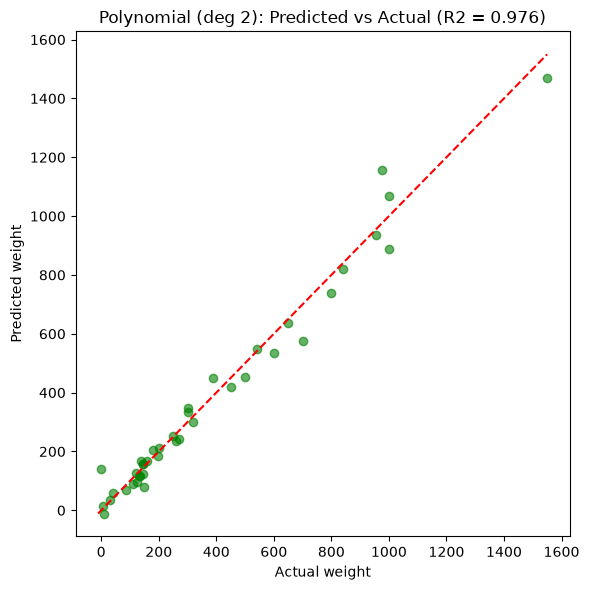

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, poly_pred, alpha=0.6, color="green")
lims = [min(y_test.min(), poly_pred.min()), max(y_test.max(), poly_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual weight")
plt.ylabel("Predicted weight")
plt.title(f"Polynomial (deg 2): Predicted vs Actual (R2 = {poly_r2:.3f})")
plt.tight_layout()
plt.show()

In [13]:
print(f"Baseline R2   : {baseline_r2:.4f}")
print(f"Polynomial R2 : {poly_r2:.4f}")

Baseline R2   : 0.8708
Polynomial R2 : 0.9755
